In [ ]:
import os
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict
import ast

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

import torch
import torch.nn as nn
from torch_geometric.data import Data, Batch, Dataset as PyGDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import subgraph, to_dense_batch
from torch_scatter import scatter_add, scatter_mean

from rdkit import Chem
from rdkit.Chem import rdchem
from Bio.PDB import PDBParser, MMCIFParser
from Bio.PDB.Polypeptide import three_to_one, is_aa
from Bio import pairwise2
from Bio.Align import substitution_matrices

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

# ==============================================================================
# 0. CONFIGURATION
# ==============================================================================
CONFIG = {
    "SEED": 42,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    
    # --- Input Paths (Adjust for Github) ---
    "DATA_DIR": Path("../data/processed/"),
    "RAW_DATA_DIR": Path("../data/raw/"),
    "PROTEIN_GRAPH_DIR": Path("../Data/Protein_Graphs_PyG/"),
    "LIGAND_GRAPH_DIR": Path("../Data/Ligand_Graphs_PyG/"),
    
    # --- Mutation Specifics ---
    "TARGET_UNIPROT_ID": "P07550", # ADRB2
    "MUTANT_PDB_FILE": Path("../data/raw/P07550_R3.50A_headless.pdb"), # User must provide this
    "WT_GRAPH_FILE": "P07550.pt",
    
    # --- Output ---
    "OUTPUT_DIR": Path("./results/mutation_study/"),
    "MUTANT_GRAPH_OUTPUT": Path("./results/mutation_study/P07550_R3.50A.pt"),
    
    # --- Model (Must match training) ---
    "MODEL_SAVE_PATH": Path("../models/saved/gpcract_final.pt"),
    "HIDDEN_DIM": 128,
    "PROTEIN_LAYERS": 4,
    "PROPAGATION_ATTENTION_LAYERS": 3,
    "ATTENTION_HEADS": 4,
    "ELEMENT_EMBEDDING_DIM": 8,
    "DROPOUT": 0.0
}

CONFIG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)

In [ ]:
# ==============================================================================
# 1. MODEL ARCHITECTURE
# ==============================================================================
def unsorted_segment_sum(data, segment_ids, num_segments):
    out = data.new_zeros((num_segments, data.size(1)))
    scatter_add(data, segment_ids, out=out, dim=0)
    return out

class E_GCL_Gated(nn.Module):
    def __init__(self, input_nf, output_nf, hidden_nf, edges_in_d=0, act_fn=nn.SiLU(), residual=True, attention=False, normalize=False, coords_agg='mean', tanh=False):
        super(E_GCL_Gated, self).__init__()
        input_edge = input_nf * 2
        self.residual = residual
        self.attention = attention
        self.normalize = normalize
        self.coords_agg = coords_agg
        self.tanh = tanh
        self.epsilon = 1e-8
        edge_coords_nf = 1

        self.edge_mlp = nn.Sequential(
            nn.Linear(input_edge + edge_coords_nf + edges_in_d, hidden_nf),
            act_fn,
            nn.Linear(hidden_nf, hidden_nf),
            act_fn)
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_nf + input_nf, hidden_nf),
            act_fn,
            nn.Linear(hidden_nf, output_nf))
        self.gate_mlp = nn.Sequential(
            nn.Linear(hidden_nf + input_nf, hidden_nf),
            act_fn,
            nn.Linear(hidden_nf, output_nf),
            nn.Sigmoid())
        self.node_norm = nn.LayerNorm(output_nf)
        
        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)
        coord_mlp_list = [nn.Linear(hidden_nf, hidden_nf), act_fn, layer]
        if self.tanh: coord_mlp_list.append(nn.Tanh())
        self.coord_mlp = nn.Sequential(*coord_mlp_list)

        if self.attention:
            self.att_mlp = nn.Sequential(nn.Linear(hidden_nf, 1), nn.Sigmoid())

    def coord2radial(self, edge_index, coord):
        row, col = edge_index
        coord_diff = coord[row] - coord[col]
        radial = torch.sum(coord_diff**2, dim=1, keepdim=True)
        if self.normalize:
            norm = torch.sqrt(radial + self.epsilon)
            coord_diff = coord_diff / norm
        return radial, coord_diff

    def edge_model(self, h_row, h_col, radial, edge_attr):
        out = torch.cat([h_row, h_col, radial] + ([edge_attr] if edge_attr is not None else []), dim=1)
        out = self.edge_mlp(out)
        if self.attention:
            out = out * self.att_mlp(out)
        return out

    def node_model(self, x, edge_index, edge_feat, node_attr=None):
        row, col = edge_index
        agg = unsorted_segment_sum(edge_feat, row, num_segments=x.size(0))
        agg_cat = torch.cat([x, agg] + ([node_attr] if node_attr is not None else []), dim=1)
        update_val = self.node_mlp(agg_cat)
        gate_val = self.gate_mlp(agg_cat)
        out = x * gate_val + (x + update_val) * (1 - gate_val) if self.residual else x * gate_val + update_val * (1 - gate_val)
        return self.node_norm(out)

    def coord_model(self, coord, edge_index, coord_diff, edge_feat):
        row, col = edge_index
        trans = coord_diff * self.coord_mlp(edge_feat)
        if self.coords_agg == 'sum':
            agg = unsorted_segment_sum(trans, row, num_segments=coord.size(0))
        elif self.coords_agg == 'mean':
            agg = unsorted_segment_sum(trans, row, num_segments=coord.size(0)) / (unsorted_segment_sum(torch.ones_like(trans), row, num_segments=coord.size(0)) + 1e-8)
        else:
            raise Exception('Wrong coords_agg parameter')
        return coord + agg

    def forward(self, h, edge_index, coord, edge_attr=None, node_attr=None):
        row, col = edge_index
        radial, coord_diff = self.coord2radial(edge_index, coord)
        e_ij = self.edge_model(h[row], h[col], radial, edge_attr)
        coord = self.coord_model(coord, edge_index, coord_diff, e_ij)
        h = self.node_model(h, edge_index, e_ij, node_attr)
        return h, coord, e_ij

class EGNN_Gated_GlobalResidual(nn.Module):
    def __init__(self, in_node_nf, hidden_nf, out_node_nf, in_edge_nf=0, n_layers=4, residual=True, attention=False, normalize=False, coords_agg='mean', tanh=False):
        super().__init__()
        self.hidden_nf = hidden_nf
        self.n_layers = n_layers
        self.embedding_in = nn.Linear(in_node_nf, hidden_nf)
        self.embedding_out = nn.Linear(hidden_nf, out_node_nf)
        for i in range(n_layers):
            self.add_module(f"gcl_{i}", E_GCL_Gated(hidden_nf, hidden_nf, hidden_nf, edges_in_d=in_edge_nf, residual=residual, attention=attention, normalize=normalize, coords_agg=coords_agg, tanh=tanh))

    def forward(self, h, coord, edge_index, edge_attr=None):
        device = self.embedding_in.weight.device
        h, coord, edge_index = h.to(device), coord.to(device), edge_index.to(device)
        if edge_attr is not None: edge_attr = edge_attr.to(device)
        h_initial = self.embedding_in(h)
        h = h_initial
        for i in range(self.n_layers):
            h, coord, _ = self._modules[f"gcl_{i}"](h, edge_index, coord, edge_attr=edge_attr)
        h = h + h_initial
        return self.embedding_out(h), coord

class GPCRact_Model(nn.Module):
    """Cleaned GPCRact Model for Mutation Analysis (No Class/Family Embeddings)"""
    def __init__(self, protein_in_dim_clean, protein_in_dim_full, ligand_in_dim, hidden_dim,
                 protein_config, ligand_config, element_embedding_dim,
                 n_attn_heads, dropout, propagation_attention_layers):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # --- Module 1: Interaction ---
        self.element_embedding = nn.Embedding(num_embeddings=6, embedding_dim=element_embedding_dim)
        self.bs_encoder = EGNN_Gated_GlobalResidual(protein_in_dim_clean, hidden_dim, hidden_dim, n_layers=protein_config['n_layers'], attention=True, tanh=True)
        self.ligand_encoder = EGNN_Gated_GlobalResidual(ligand_in_dim, hidden_dim, hidden_dim, n_layers=ligand_config['n_layers'], attention=True, tanh=True)
        
        self.p_to_l_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=n_attn_heads, dropout=dropout, batch_first=True)
        self.l_to_p_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=n_attn_heads, dropout=dropout, batch_first=True)

        # --- Module 2: Local Propagation ---
        self.local_propagation_encoder = EGNN_Gated_GlobalResidual(hidden_dim, hidden_dim, hidden_dim, n_layers=protein_config['n_layers'], attention=True, tanh=True)
        self.protein_embedding_ca = nn.Linear(protein_in_dim_full, hidden_dim)
        self.protein_embedding_sc = nn.Linear(protein_in_dim_full, hidden_dim)

        # --- Module 3: Global Propagation ---
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_attn_heads, dim_feedforward=hidden_dim * 4, dropout=dropout, batch_first=True)
        self.global_integration_transformer = nn.TransformerEncoder(encoder_layer, num_layers=propagation_attention_layers)
        self.final_norm = nn.LayerNorm(hidden_dim)

        # --- Module 4: Heads ---
        self.binding_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))
        self.activity_type_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, 2))

    def forward(self, protein_batch, ligand_batch):
        # 1. Interaction
        bs_mask = protein_batch.bs_mask
        bs_edge_index, _ = subgraph(bs_mask, protein_batch.edge_index, relabel_nodes=True, num_nodes=protein_batch.num_nodes)
        
        p_features_bs = torch.cat([protein_batch.x_float_clean[bs_mask], self.element_embedding(protein_batch.x_elem[bs_mask])], dim=1)
        h_p_bs, _ = self.bs_encoder(p_features_bs, protein_batch.pos[bs_mask], bs_edge_index)
        h_l, _ = self.ligand_encoder(ligand_batch.x, ligand_batch.pos, ligand_batch.edge_index)

        padded_bs, mask_bs = to_dense_batch(h_p_bs, protein_batch.batch[bs_mask])
        padded_l, mask_l = to_dense_batch(h_l, ligand_batch.batch)

        p_updated, _ = self.p_to_l_attention(query=padded_bs, key=padded_l, value=padded_l, key_padding_mask=~mask_l)
        l_updated, _ = self.l_to_p_attention(query=padded_l, key=padded_bs, value=padded_bs, key_padding_mask=~mask_bs)
        p_updated[~mask_bs] = 0
        l_updated[~mask_l] = 0

        p_vec = p_updated.sum(dim=1) / mask_bs.sum(dim=1, keepdim=True).clamp(min=1)
        l_vec = l_updated.sum(dim=1) / mask_l.sum(dim=1, keepdim=True).clamp(min=1)
        binding_logit = self.binding_head(torch.cat([p_vec, l_vec], dim=1))

        # 2. Propagation
        ligand_signal = p_updated[mask_bs]
        gate_weight = torch.sigmoid(binding_logit).squeeze(-1)[protein_batch.batch].unsqueeze(-1)
        gated_signal = ligand_signal * gate_weight[bs_mask]

        p_features_full = torch.cat([protein_batch.x_float_full, self.element_embedding(protein_batch.x_elem)], dim=1)
        h = torch.zeros(p_features_full.size(0), self.hidden_dim, device=p_features_full.device)
        ca_mask, sc_mask = (protein_batch.node_roles == 0), (protein_batch.node_roles == 1)
        h[ca_mask] = self.protein_embedding_ca(p_features_full[ca_mask]).to(h.dtype)
        h[sc_mask] = self.protein_embedding_sc(p_features_full[sc_mask]).to(h.dtype)

        h_init = h.clone()
        coords = protein_batch.pos.clone()
        
        for i in range(self.local_propagation_encoder.n_layers):
            h[bs_mask] = h[bs_mask] + gated_signal
            h, coords, _ = self.local_propagation_encoder._modules[f"gcl_{i}"](h, protein_batch.edge_index, coords)
        
        h = self.final_norm(self.local_propagation_encoder.embedding_out(h + h_init))

        # 3. Global Integration & Activity Prediction (No class embeddings)
        padded_h, mask_p = to_dense_batch(h, protein_batch.batch)
        final_h = self.global_integration_transformer(padded_h, src_key_padding_mask=~mask_p)[mask_p]
        pool_p = scatter_mean(final_h, protein_batch.batch, dim=0)
        activity_logit = self.activity_type_head(torch.cat([pool_p, l_vec], dim=1))
        
        return binding_logit, activity_logit

In [ ]:
# ==============================================================================
# 2. MUTANT GRAPH GENERATION
# ==============================================================================
# --- Atom Selection Logic ---
KEY_ATOMS_MAP = {
    'ALA': ['CB'], 'VAL': ['CG1', 'CG2'], 'LEU': ['CD1', 'CD2'], 'ILE': ['CG2', 'CD1'],
    'PRO': ['CD'], 'PHE': ['CZ'], 'TYR': ['CZ', 'OH'], 'TRP': ['NE1', 'CH2'],
    'SER': ['OG'], 'THR': ['OG1', 'CG2'], 'CYS': ['SG'], 'ASN': ['OD1', 'ND2'],
    'GLN': ['OE1', 'NE2'], 'MET': ['SD', 'CE'], 'ASP': ['OD1', 'OD2'],
    'GLU': ['OE1', 'OE2'], 'LYS': ['NZ'], 'ARG': ['CZ', 'NH2'], 'HIS': ['ND1', 'NE2']
}

def select_representative_atoms(residue_obj):
    if 'CA' not in residue_obj: return None, []
    ca_atom = residue_obj['CA']
    ca_coord = ca_atom.get_coord()
    selected_atoms = set()

    # Rule 1: Furthest heavy atom
    max_dist, furthest_atom = 0.0, None
    for atom in residue_obj.get_atoms():
        if atom.element != 'H':
            dist = np.linalg.norm(atom.get_coord() - ca_coord)
            if dist > max_dist:
                max_dist = dist; furthest_atom = atom
    if furthest_atom and furthest_atom.get_name() != 'CA':
        selected_atoms.add(furthest_atom)

    # Rule 2: Key functional atoms
    key_atom_names = KEY_ATOMS_MAP.get(residue_obj.get_resname(), [])
    for atom_name in key_atom_names:
        if atom_name in residue_obj: selected_atoms.add(residue_obj[atom_name])

    return ca_atom, list(selected_atoms)

def get_rdkit_features(pdb_path, chain_id):
    if not Path(pdb_path).exists(): return {}
    try:
        mol = Chem.MolFromPDBFile(str(pdb_path), removeHs=True)
        if not mol: return {}
    except: return {}

    rdkit_map = {}
    hybridization_types = [rdchem.HybridizationType.SP, rdchem.HybridizationType.SP2, rdchem.HybridizationType.SP3, rdchem.HybridizationType.SP3D, rdchem.HybridizationType.SP3D2]

    for atom in mol.GetAtoms():
        info = atom.GetPDBResidueInfo()
        if info and info.GetChainId().strip() == chain_id:
            res, name = info.GetResidueNumber(), info.GetName().strip()
            hybrid = atom.GetHybridization()
            h_hybrid = [1.0 if hybrid == h else 0.0 for h in hybridization_types]
            rdkit_map[(res, name)] = [float(atom.GetFormalCharge()), float(atom.GetIsAromatic())] + h_hybrid
    return rdkit_map

def create_uniprot_to_pdb_res_map(chain_obj, uniprot_seq):
    pdb_res_list = [res for res in chain_obj if is_aa(res, standard=True)]
    if not pdb_res_list: return None
    pdb_seq = "".join([three_to_one(res.get_resname()) for res in pdb_res_list])
    
    alignments = pairwise2.align.localds(uniprot_seq, pdb_seq, matlist.blosum62, -10, -0.5)
    if not alignments: return None
    
    aligned_uni, aligned_pdb = alignments[0][:2]
    mapping, pdb_idx, uni_pos = {}, 0, 0
    for u_char, p_char in zip(aligned_uni, aligned_pdb):
        if u_char != '-': uni_pos += 1
        if p_char != '-':
            if u_char != '-': mapping[uni_pos] = pdb_res_list[pdb_idx]
            pdb_idx += 1
    return mapping

def generate_mutant_graph(config):
    print(f"--- Generating Mutant Graph for {config['TARGET_UNIPROT_ID']} ---")
    
    # 1. Load Reference Data (Need Sequence and WT Residue Set)
    try:
        # We load the WT graph to get the target residue set (BS + DR)
        wt_graph = torch.load(config['PROTEIN_GRAPH_DIR'] / config['WT_GRAPH_FILE'])
        target_residues = wt_graph.node_res_num.tolist() # List of residues to extract
        bs_mask_set = set(wt_graph.node_res_num[wt_graph.bs_mask].tolist()) # Binding site residues
        
        # Load Sequence
        seq_df = pd.read_csv(config['RAW_DATA_DIR'] / "Human_GPCR_PDB_Info.csv")
        sequence = seq_df[seq_df['Entry'] == config['TARGET_UNIPROT_ID']]['Sequence'].values[0]
    except Exception as e:
        print(f"Prerequisite data missing: {e}. Ensure WT graph and Seq info exist.")
        return None

    # 2. Load Mutant PDB
    if not config['MUTANT_PDB_FILE'].exists():
        print(f"Mutant PDB {config['MUTANT_PDB_FILE']} not found.")
        return None

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("MUTANT", str(config['MUTANT_PDB_FILE']))
    chain = structure[0]['A']
    
    # 3. Map UniProt to PDB
    uni_to_pdb = create_uniprot_to_pdb_res_map(chain, sequence)
    if not uni_to_pdb: return None

    # 4. Extract Nodes & Features
    rdkit_feats = get_rdkit_features(config['MUTANT_PDB_FILE'], 'A')
    AA_CODES = "ACDEFGHIKLMNPQRSTVWY"
    ELEMENT_MAP = {e: i for i, e in enumerate(['C', 'O', 'N', 'S', 'P', 'OTHER'])}
    default_rdkit = [0.0] * 7

    node_atoms, node_features, node_roles = [], [], []
    node_res_nums, bs_mask_list = [], []

    for res_num in target_residues:
        res_obj = uni_to_pdb.get(res_num)
        if not res_obj: continue
        
        ca, reps = select_representative_atoms(res_obj)
        if not ca: continue
        
        # Helper to process atom
        def process_atom(atom, role_id, dist_ca=0.0):
            res_name_1 = three_to_one(res_obj.get_resname()) if is_aa(res_obj) else 'X'
            
            # Features: [AA_Type(20), IsBS(1), Disp(2), Element(6), RelPos(3), Dist(1), RDKit(7)]
            h_res = [1.0 if res_name_1 == c else 0.0 for c in AA_CODES]
            is_bs = [1.0] if res_num in bs_mask_set else [0.0]
            # Important: For mutant, we can assume displacements are 0 or copy WT. 
            # Here we set to 0 as a conservative baseline for the structure.
            h_disp = [0.0, 0.0] 
            
            elem_idx = [ELEMENT_MAP.get(atom.element, ELEMENT_MAP['OTHER'])]
            rel_pos = list(atom.get_coord() - ca.get_coord())
            h_dist = [dist_ca]
            h_rdkit = rdkit_feats.get((res_obj.get_id()[1], atom.get_name().strip()), default_rdkit)
            
            feat = h_res + is_bs + h_disp + elem_idx + rel_pos + h_dist + h_rdkit
            
            node_atoms.append(atom)
            node_features.append(feat)
            node_roles.append(role_id)
            node_res_nums.append(res_num)
            bs_mask_list.append(res_num in bs_mask_set)

        # Process CA
        process_atom(ca, 0, 0.0)
        # Process Sidechains
        for atom in reps:
            dist = np.linalg.norm(atom.get_coord() - ca.get_coord())
            process_atom(atom, 1, dist)

    if len(node_atoms) < 10: return None
    
    # 5. Build Edge Index (KNN)
    pos = torch.tensor([a.get_coord() for a in node_atoms], dtype=torch.float)
    k = min(64, len(node_atoms) - 1)
    tree = KDTree(pos.numpy())
    _, indices = tree.query(pos.numpy(), k=k + 1)
    edge_index = torch.tensor([(i, n) for i, neighbors in enumerate(indices) for n in neighbors[1:]], dtype=torch.long).t()

    # 6. Construct Data Object
    # Note: We add dummy class/family IDs just to match PyG batching structure if needed by loader,
    # though model ignores them.
    mutant_graph = Data(
        x=torch.tensor(node_features, dtype=torch.float),
        pos=pos,
        edge_index=edge_index,
        node_res_num=torch.tensor(node_res_nums, dtype=torch.long),
        node_role=torch.tensor(node_roles, dtype=torch.long),
        bs_mask=torch.tensor(bs_mask_list, dtype=torch.bool),
        gpcr_class_id=torch.tensor([0]), 
        gpcr_family_id=torch.tensor([0])
    )
    
    torch.save(mutant_graph, config['MUTANT_GRAPH_OUTPUT'])
    print(f"✅ Mutant graph saved to {config['MUTANT_GRAPH_OUTPUT']}")
    return mutant_graph

# Execute Generation
generate_mutant_graph(CONFIG) # Uncomment to run generation

Loading data from: ./revision/analysis_results/experiment1_prediction_failure.csv

--- [Generating Plot for R2-C4: Causality Test] ---


/tmp/ipykernel_524168/1151940550.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


✅ Plot saved to: revision/analysis_results/R2-C4_Causality_Plot_P07550.png


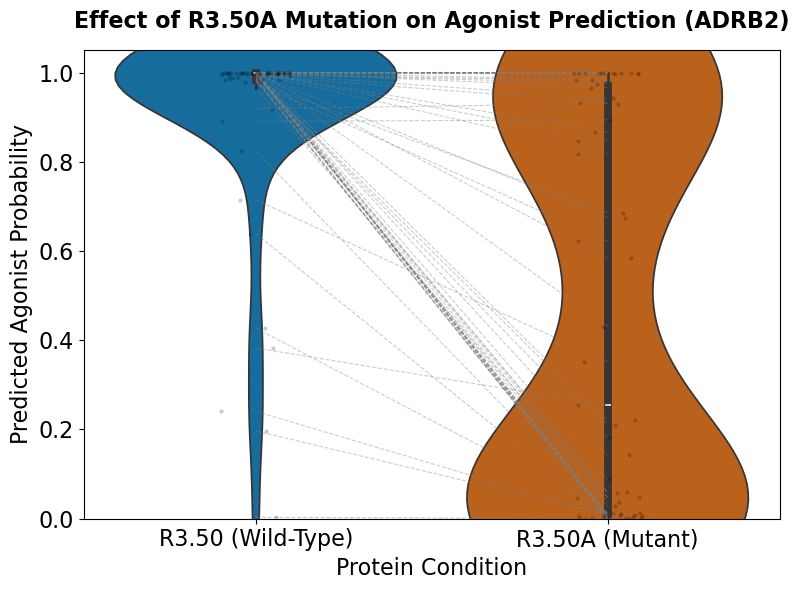

In [97]:
# ==============================================================================
# 3. INFERENCE & VISUALIZATION
# ==============================================================================

def preprocess_graph(p):
    """Feature slicing wrapper."""
    p = p.clone()
    x = p.x
    # Slice features: AA(20)|BS(1)|Disp(2)|Elem(1)|Rel(3)|Dist(1)|RDKit(7)
    h_res = x[:, :20]; h_bs = x[:, 20:21]; h_disp = x[:, 21:23]
    x_elem_onehot = x[:, 23:29]
    p.x_elem = torch.argmax(x_elem_onehot, dim=1).long()
    
    h_rel = x[:, 29:32]; h_dist = x[:, 32:33]; h_rdkit = x[:, 33:]
    
    p.x_float_full = torch.cat([h_res, h_bs, h_disp, h_rel, h_dist, h_rdkit], dim=1)
    p.x_float_clean = torch.cat([h_res, h_rel, h_dist, h_rdkit], dim=1)
    p.node_roles = p.node_role
    return p

def run_causality_analysis():
    print("--- Starting Causality Analysis ---")
    
    # 1. Load Graphs
    try:
        p_wt = torch.load(CONFIG['PROTEIN_GRAPH_DIR'] / CONFIG['WT_GRAPH_FILE'])
        p_mut = torch.load(CONFIG['MUTANT_GRAPH_OUTPUT'])
        
        p_wt = preprocess_graph(p_wt)
        p_mut = preprocess_graph(p_mut)
        
        p_batch_wt = Batch.from_data_list([p_wt]).to(CONFIG['DEVICE'])
        p_batch_mut = Batch.from_data_list([p_mut]).to(CONFIG['DEVICE'])
    except Exception as e:
        print(f"Error loading graphs: {e}. Make sure mutant graph is generated.")
        return

    # 2. Load Model
    # Dummy load for dimensions
    p_in_clean = p_wt.x_float_clean.shape[1] + CONFIG['ELEMENT_EMBEDDING_DIM']
    p_in_full = p_wt.x_float_full.shape[1] + CONFIG['ELEMENT_EMBEDDING_DIM']
    
    model = GPCRact_Model(
        protein_in_dim_clean=p_in_clean,
        protein_in_dim_full=p_in_full,
        ligand_in_dim=19,
        hidden_dim=CONFIG['HIDDEN_DIM'],
        protein_config={"type": "gated_residual", "n_layers": 4},
        ligand_config={"type": "gated_residual", "n_layers": 4},
        element_embedding_dim=CONFIG['ELEMENT_EMBEDDING_DIM'],
        dropout=0.0,
        n_attn_heads=CONFIG['ATTENTION_HEADS'],
        propagation_attention_layers=CONFIG['PROPAGATION_ATTENTION_LAYERS']
    )
    
    # Load weights
    state = torch.load(CONFIG['MODEL_SAVE_PATH'], map_location=CONFIG['DEVICE'])
    model.load_state_dict(state, strict=False)
    model.to(CONFIG['DEVICE'])
    model.eval()

    # 3. Find Agonists
    try:
        test_df = pd.read_csv(CONFIG['PREDICTIONS_TEST_PATH'])
        agonists = test_df[
            (test_df['UniProt'] == CONFIG['TARGET_UNIPROT_ID']) & 
            (test_df['Final_Label'] == 2) & # Agonist
            (test_df['Binding_Prob'] > 0.5)
        ]['Ikey'].unique()
    except:
        print("Could not load predictions. Exiting.")
        return

    print(f"Evaluating {len(agonists)} Agonists...")
    results = []

    with torch.no_grad():
        for ikey in tqdm(agonists):
            l_path = CONFIG['LIGAND_GRAPH_DIR'] / f"{ikey}.pt"
            if not l_path.exists(): continue
            l_graph = torch.load(l_path)
            l_batch = Batch.from_data_list([l_graph]).to(CONFIG['DEVICE'])

            # WT
            b_wt, a_wt = model(p_batch_wt, l_batch)
            prob_wt_ago = torch.softmax(a_wt, dim=1)[0, 1].item()

            # MUT
            b_mut, a_mut = model(p_batch_mut, l_batch)
            prob_mut_ago = torch.softmax(a_mut, dim=1)[0, 1].item()

            results.append({'ikey': ikey, 'prob_wt': prob_wt_ago, 'prob_mut': prob_mut_ago})

    # 4. Plotting
    if not results: return
    
    df_res = pd.DataFrame(results)
    df_res.to_csv(CONFIG['OUTPUT_DIR'] / "mutation_results.csv", index=False)
    
    # Plot
    plot_df = df_res.melt(id_vars=['ikey'], value_vars=['prob_wt', 'prob_mut'], 
                          var_name='Condition', value_name='Agonist Probability')
    plot_df['Condition'] = plot_df['Condition'].map({'prob_wt': 'Wild-Type (R3.50)', 'prob_mut': 'Mutant (R3.50A)'})

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=plot_df, x='Condition', y='Agonist Probability', palette=['#0072B2', '#D55E00'])
    sns.stripplot(data=plot_df, x='Condition', y='Agonist Probability', color='black', alpha=0.3, jitter=True)
    
    # Connect lines
    for i in range(len(df_res)):
        plt.plot([0, 1], [df_res.iloc[i]['prob_wt'], df_res.iloc[i]['prob_mut']], color='gray', alpha=0.2, linewidth=0.5)

    plt.title(f"Causal Effect of R3.50A Mutation on Agonist Prediction", fontsize=14, fontweight='bold')
    plt.ylabel("Predicted Agonist Probability")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CONFIG['OUTPUT_DIR'] / "FigureS_Causality_Check.png", dpi=300)
    print("Plot saved.")
    plt.show()

# Run
run_causality_analysis()